# Análisis Exploratorio de Datos — Costos Médicos

Este notebook explora el dataset `insurance.csv` para entender la distribución de las variables, detectar patrones visuales y cuantificar las correlaciones que justifican la selección de features para el modelo predictivo.

## Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

IMG_PATH = Path("../../images")
IMG_PATH.mkdir(exist_ok=True)

## 1. Carga del dataset

Se carga el archivo `insurance.csv` con 1.338 registros y 7 variables: `age`, `sex`, `bmi`, `children`, `smoker`, `region` y `charges`.

In [2]:
df_path = Path("../../data/insurance.csv")
df_insurance = pd.read_csv(df_path)
print(df_insurance)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


## 2. Análisis estadístico descriptivo

Revisión de la estructura del dataset: dimensiones, tipos de datos, valores nulos y métricas de resumen por variable.

### 2.1 Dimensiones del dataset

In [3]:
df_insurance.shape

(1338, 7)

### 2.2 Tipos de datos y valores nulos

In [4]:
df_insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


### 2.3 Estadísticas descriptivas

In [5]:
df_insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Análisis visual

### 3.1 Distribución de costos médicos

Histograma con curva KDE para observar la forma de la distribución de `charges`. Se espera sesgo positivo dado que una minoría de pacientes concentra costos muy elevados.

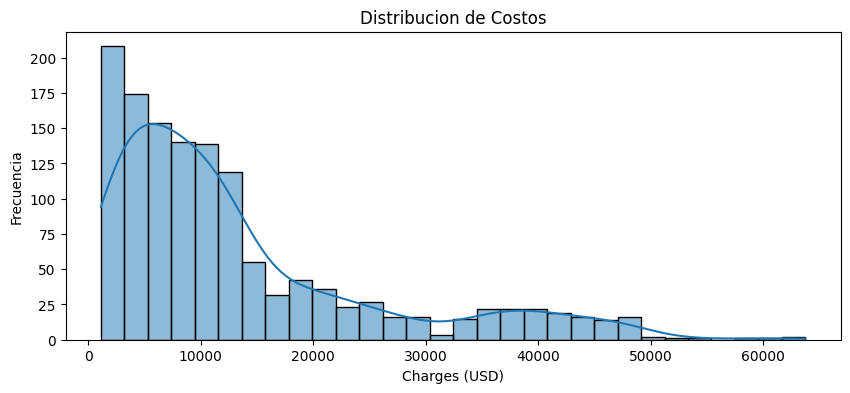

In [6]:
plt.figure(figsize=(10,4))
sns.histplot(data=df_insurance, x='charges', bins=30, kde=True)
plt.title('Distribucion de Costos')
plt.xlabel('Charges (USD)')
plt.ylabel('Frecuencia')
plt.savefig(IMG_PATH / "01_distribucion_costos.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Distribución de costos por hábito tabáquico

Se separa la distribución de `charges` entre fumadores y no fumadores para evaluar el impacto de `smoker` sobre los costos.

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(data=df_insurance, x='charges', bins=30, kde=True, hue='smoker')
plt.title('Distribucion de Costos por Fumador')
plt.xlabel('Charges (USD)')
plt.ylabel('Frecuencia')
plt.savefig(IMG_PATH / "02_charges_by_smoker.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Distribución de BMI por hábito tabáquico

Histograma de `bmi` segmentado por `smoker` para identificar si la distribución de peso difiere entre ambos grupos.

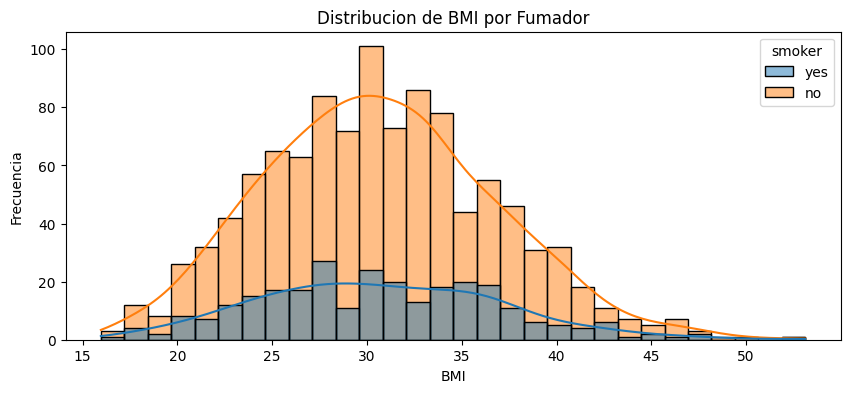

In [8]:
plt.figure(figsize=(10,4))
sns.histplot(data=df_insurance, x='bmi', bins=30, kde=True, hue='smoker')
plt.title('Distribucion de BMI por Fumador')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.savefig(IMG_PATH / "03_bmi_por_fumador.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Relación BMI vs. costos médicos

Diagrama de dispersión que cruza `bmi` con `charges`, coloreado por `smoker`. Permite visualizar si la combinación obesidad + tabaquismo genera un segmento de alto costo diferenciado.

In [ ]:
plt.figure(figsize=(10,4))
sns.scatterplot(data=df_insurance, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.title('BMI vs Charges por Smoker')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.savefig(IMG_PATH / "04_bmi_vs_charges.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Relación edad vs. costos médicos

Diagrama de dispersión entre `age` y `charges` segmentado por `smoker`. Se espera una tendencia creciente con la edad, más pronunciada en fumadores.

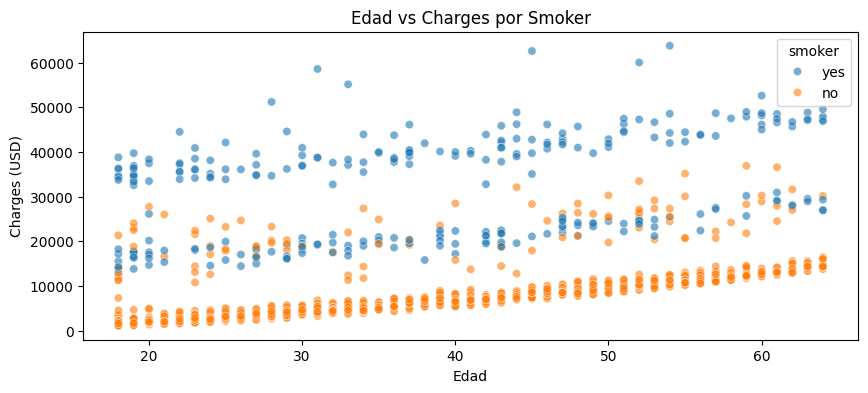

In [10]:
plt.figure(figsize=(10,4))
sns.scatterplot(data=df_insurance, x='age', y='charges', hue='smoker', alpha=0.6)
plt.title('Edad vs Charges por Smoker')
plt.xlabel('Edad')
plt.ylabel('Charges (USD)')
plt.savefig(IMG_PATH / "05_edad_vs_charges.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Ingeniería de variables

### 4.1 Variable `obese`

Se crea una variable binaria a partir de `bmi`: 1 si BMI ≥ 30 (criterio clínico de obesidad), 0 en caso contrario.

In [11]:
df_insurance['obese'] = (df_insurance['bmi'] >= 30).astype(int)
print(df_insurance)

      age     sex     bmi  children smoker     region      charges  obese
0      19  female  27.900         0    yes  southwest  16884.92400      0
1      18    male  33.770         1     no  southeast   1725.55230      1
2      28    male  33.000         3     no  southeast   4449.46200      1
3      33    male  22.705         0     no  northwest  21984.47061      0
4      32    male  28.880         0     no  northwest   3866.85520      0
...   ...     ...     ...       ...    ...        ...          ...    ...
1333   50    male  30.970         3     no  northwest  10600.54830      1
1334   18  female  31.920         0     no  northeast   2205.98080      1
1335   18  female  36.850         0     no  southeast   1629.83350      1
1336   21  female  25.800         0     no  southwest   2007.94500      0
1337   61  female  29.070         0    yes  northwest  29141.36030      0

[1338 rows x 8 columns]


### 4.2 Codificación binaria de `smoker`

Se convierte `smoker` de texto (`yes`/`no`) a entero (1/0) para habilitar su uso en modelos numéricos y en la matriz de correlación.

In [12]:
df_insurance['smoker'] = (df_insurance['smoker'] == "yes").astype(int)
print(df_insurance)

      age     sex     bmi  children  smoker     region      charges  obese
0      19  female  27.900         0       1  southwest  16884.92400      0
1      18    male  33.770         1       0  southeast   1725.55230      1
2      28    male  33.000         3       0  southeast   4449.46200      1
3      33    male  22.705         0       0  northwest  21984.47061      0
4      32    male  28.880         0       0  northwest   3866.85520      0
...   ...     ...     ...       ...     ...        ...          ...    ...
1333   50    male  30.970         3       0  northwest  10600.54830      1
1334   18  female  31.920         0       0  northeast   2205.98080      1
1335   18  female  36.850         0       0  southeast   1629.83350      1
1336   21  female  25.800         0       0  southwest   2007.94500      0
1337   61  female  29.070         0       1  northwest  29141.36030      0

[1338 rows x 8 columns]


## 5. Matriz de correlación

Heatmap con los coeficientes de correlación de Pearson entre todas las variables numéricas. Permite identificar las variables con mayor relación lineal con `charges` y fundamentar la selección de features para el modelo.

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_insurance.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f')
plt.title('Matriz de Correlación')
plt.savefig(IMG_PATH / "06_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()